In [11]:
%load_ext autoreload
%autoreload

from methods.data_generation import DataGeneration
from methods.constants import NetworkSettings, DataGenerationSettings

import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


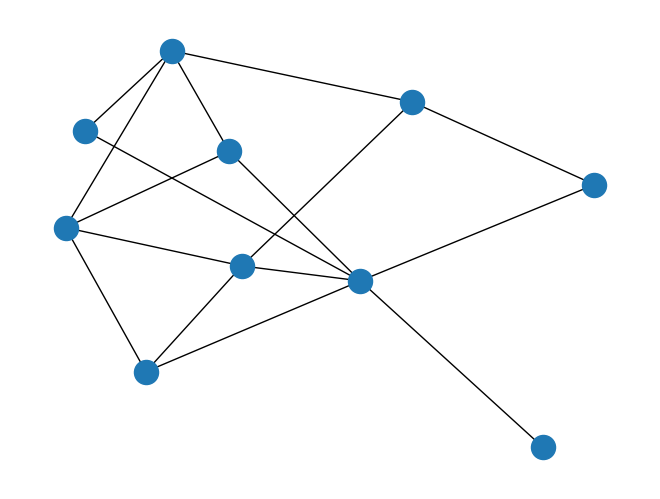

In [13]:
# different networks
G = nx.erdos_renyi_graph(10, 0.4)
nx.draw(G)

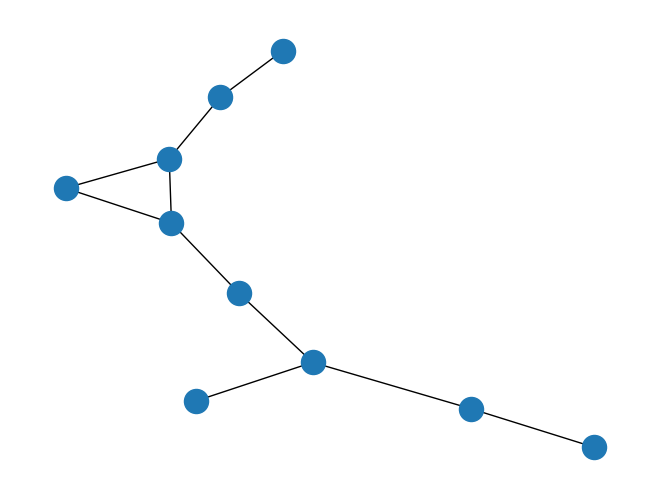

In [14]:
G = nx.watts_strogatz_graph(10, k=2, p=0.5)
nx.draw(G)

In [6]:
# initialization 
network_settings = NetworkSettings()
dgp_settings = DataGenerationSettings()
data_generation = DataGeneration(
    n_nodes = network_settings.n_nodes,
    n_edges=network_settings.n_edges,
    n_features=dgp_settings.n_features,
    beta_mean=dgp_settings.beta_mean,
    beta_std=dgp_settings.beta_std,
    error_mean=dgp_settings.error_mean,
    error_std=dgp_settings.error_std,
    cov_mean_range=dgp_settings.cov_mean_range,
    cov_std_range=dgp_settings.cov_std_range,
    share_treatment=dgp_settings.share_treatment,
    treatment_effect_mean=dgp_settings.treatment_effect_mean,
    treatment_effect_std=dgp_settings.treatment_effect_std,
    n_influence_list=dgp_settings.n_influence_list,
    n_sim=dgp_settings.n_sim
)

In [7]:
covariates = data_generation.generate_random_covariates()

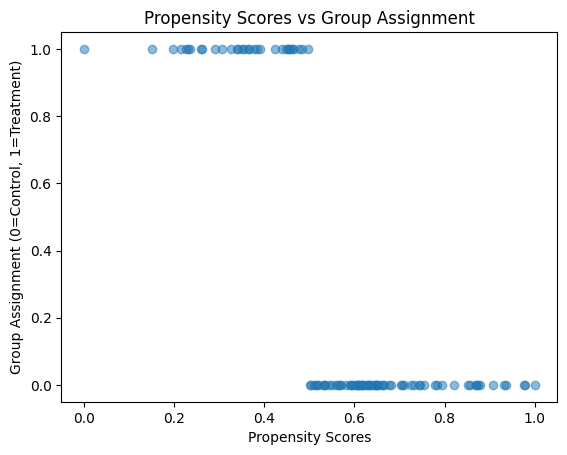

In [9]:
# Check correlation between propensity scores and group assignment

weights = np.random.normal(size=covariates.shape[1])  # Simulate random weights
propensity_scores = np.dot(covariates, weights)
propensity_scores = (propensity_scores - propensity_scores.min()) / (propensity_scores.max() - propensity_scores.min())  # Normalize to [0, 1]
group_assignment = (propensity_scores < dgp_settings.share_treatment).astype(int)

plt.scatter(propensity_scores, group_assignment, alpha=0.5)
plt.xlabel("Propensity Scores")
plt.ylabel("Group Assignment (0=Control, 1=Treatment)")
plt.title("Propensity Scores vs Group Assignment")
plt.show()